In [ ]:
# Q1: Load dataset and basic understanding
import pandas as pd

# Upload file first
from google.colab import files
uploaded = files.upload()

# Load Excel file
df = pd.read_excel("loan_approval.xlsx")

# a) Display first 5 rows
print("Head of dataset:")
print(df.head())

# b) Shape of dataset
print("\nShape:", df.shape)

# c) Data types of each column
print("\nData types:")
print(df.dtypes)


Saving loan_approval.xlsx to loan_approval.xlsx
Head of dataset:
              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  

Shape: (2000, 8)

Data types:
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       

In [ ]:
# Q2: Data Cleaning
# a) Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# b) Handle missing values (example: fill numeric with median, categorical with mode)
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=['object','bool']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# c) Identify categorical columns
categorical_cols = df.select_dtypes(include=['object','bool']).columns.tolist()
print("\nCategorical columns:", categorical_cols)


Missing values per column:
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

Categorical columns: ['name', 'city', 'loan_approved']


/tmp/ipykernel_3738/1808721950.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3738/1808721950.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

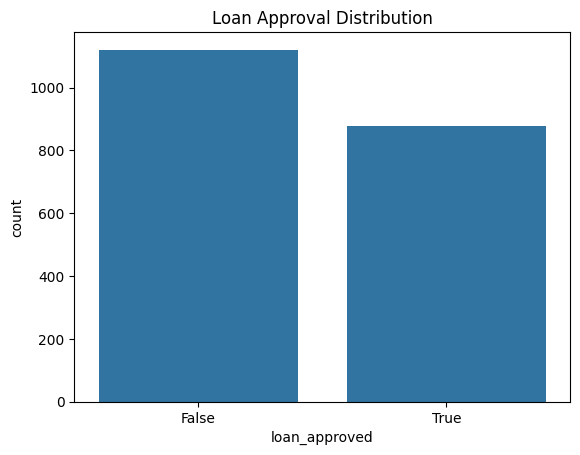

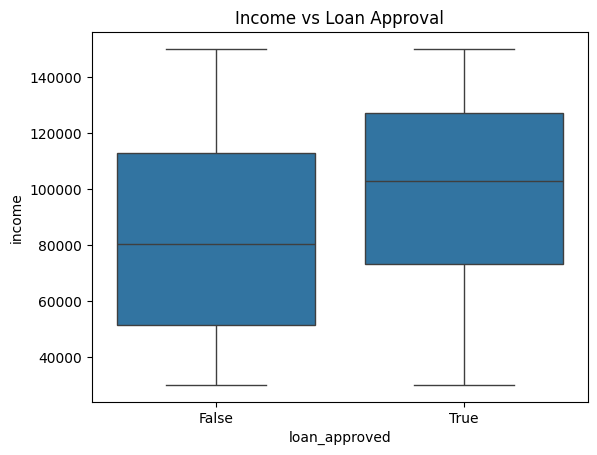

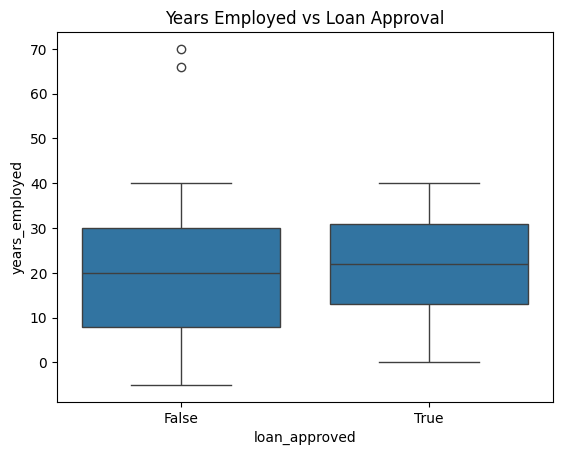

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# a) Distribution of target variable
sns.countplot(x="loan_approved", data=df)
plt.title("Loan Approval Distribution")
plt.show()

# b) Relationship between income and loan approval
sns.boxplot(x="loan_approved", y="income", data=df)
plt.title("Income vs Loan Approval")
plt.show()

# c) Relationship between years_employed and loan approval
sns.boxplot(x="loan_approved", y="years_employed", data=df)
plt.title("Years Employed vs Loan Approval")
plt.show()


In [ ]:
import numpy as np

# Q4: Outlier Detection using IQR
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

# Q4b: Treat outliers using capping
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))


income: 0 outliers
credit_score: 3 outliers
loan_amount: 0 outliers
years_employed: 2 outliers
points: 0 outliers


In [ ]:
# Q5: Convert target variable and drop unnecessary columns

# Convert loan_approved (True/False) → 1/0
df['loan_approved'] = df['loan_approved'].astype(int)

# Drop unnecessary columns (name, city)
df_cleaned = df.drop(['name', 'city'], axis=1)

print("Updated dataset:")
print(df_cleaned.head())
print("\nShape:", df_cleaned.shape)


Updated dataset:
     income  credit_score  loan_amount  years_employed  points  loan_approved
0  113810.0         389.0      39698.0            27.0    50.0              0
1   44592.0         729.0      15446.0            28.0    55.0              0
2   33278.0         584.0      11189.0            13.0    45.0              0
3  127196.0         344.0      48823.0            29.0    50.0              0
4   66048.0         496.0      47174.0             4.0    25.0              0

Shape: (2000, 6)


In [ ]:
#Q6: Feature Selection & Data Splitting
from sklearn.model_selection import train_test_split

# a) Separate independent variables (X) and dependent variable (y)
X = df_cleaned.drop('loan_approved', axis=1)
y = df_cleaned['loan_approved']

print("Features selected:", X.columns.tolist())
print("Target variable:", y.name)

# b) Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Features selected: ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']
Target variable: loan_approved

Training set size: (1600, 5)
Testing set size: (400, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Q7: Apply feature scaling
scaler = StandardScaler()

# Fit on training data and transform both train & test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training set shape:", X_train_scaled.shape)
print("Scaled testing set shape:", X_test_scaled.shape)


Scaled training set shape: (1600, 5)
Scaled testing set shape: (400, 5)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Q8: Train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)  # increase iterations for convergence
log_reg.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = log_reg.predict(X_test_scaled)

print("Predictions (first 10):", y_pred[:10])


Predictions (first 10): [0 1 1 1 1 1 0 1 0 1]


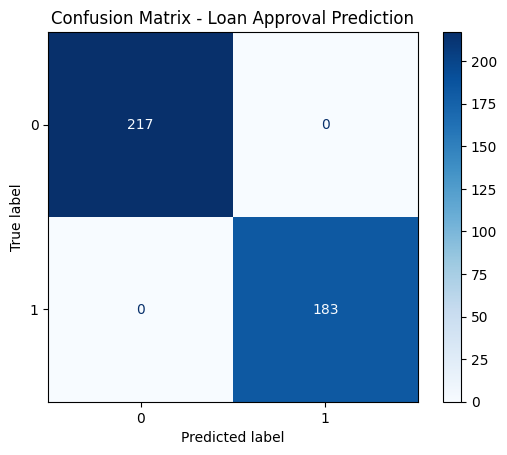

Confusion Matrix:
 [[217   0]
 [  0 183]]


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Q9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Loan Approval Prediction")
plt.show()

print("Confusion Matrix:\n", cm)


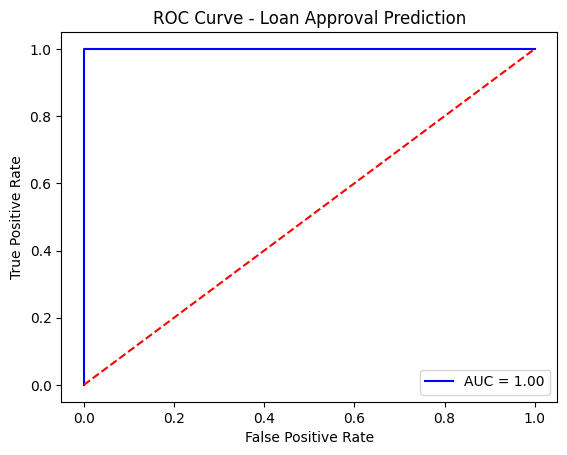

AUC Score: 1.0


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Q10: ROC Curve & AUC
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:,1]  # probabilities for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], color='red', linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Loan Approval Prediction")
plt.legend()
plt.show()

print("AUC Score:", auc_score)
